In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from numba import jit

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
from scipy.signal import find_peaks
from scipy.integrate import quad
from scipy.optimize import root_scalar
from matplotlib.animation import PillowWriter, FuncAnimation

print("Fin")

Fin


In [2]:
# Independent parameters (free to edit)

Na = 0.5 # Units: M 
T = 303.15 # Units: K
valence = 4
duration = 500 * 10**5 # In timesteps of dt
gridpoints = 128 # Number of points
dx = 10 # Units: nm
dt = 1.E-5 # Units: sec
rho_mean = 9E-5 # Initial mean density of nanostar A, found by spinodal (rho dense + rho dilute)/2 for the value of T used
save_interval = 10**5

grid_length = dx * gridpoints # Total length (nm)
inv_dx2= 1.0 / (dx * dx)

#Establishes constants
K = 1.0E6 # Units: nm^5 
M = 1 # Units: (nm s)^-1
B2 = 2190 # Units: nm^3
vb = 1.66 # Units: nm^3
kB = 1.314E-23*0.24 # Units: cal/K (1J=0.24cal)
mol = 6.02E23
dHa = -42000 # Units: cal/mol 
dS1 = 1.84*np.log(Na) # Units: cal/mol K
dS0 = -120 # Units: cal/mol K at 1M NaCl
floor = 1E-12 # Minimum value for arrays
num_saves = duration // save_interval + 1 #Number of saved values

Da = vb * np.exp(-(dHa - T * (dS0 + dS1)) / (mol * kB * T))
Db = Da

print("Fin")

Fin


In [3]:
# Initializes array of density values
np.random.seed(7) # Opens a random number generator instance, seed 7


rho = rho_mean * (1.0 + 0.01 * np.random.uniform(low=-1, high=1, size=gridpoints)) # Creates rho values around the mean with slight randomness
rho = np.maximum(rho, 1.E-10)  # Prevents negative densities

initial_mass = np.sum(rho)

Ts = np.arange(296.15,310.15, 1)
rho_min_max = (1.E-9,32.E-4)
drho = 1.E-8
rhoAs = np.arange(rho_min_max[0],rho_min_max[1],drho)



# AAAA by itself
# Finds chemical potential of reference system
def murel(rhoA):
    return np.log(rhoA)+2*B2*rhoA

# Finds chemical potential from bonding
def mubond(rhoA,Da, valence):
    x = valence*Da*rhoA
    Xa = (-1+np.sqrt(1+4*x))/(2*x)
    return valence*np.log(Xa)

# Finds total chemical potential
def f(rho):
    return murel(rho)+mubond(rho, Da, valence)


'''

# ABBB by itself
# Finds chemical potential of reference system
def murel(rho):
    return np.log(rho)+2*B2*rho

# Finds chemical potential from bonding
def mubond(rho,Da, valence):
    Ca = 0.25 * valence*Da*rho
    Cb = 0.75 * valence*Db*rho
    Xa = (-1+np.sqrt(1+4*Ca))/(2*Ca)
    Xb = (-1+np.sqrt(1+4*Cb))/(2*Cb)
    return ((valence/4)*(np.log(Xa)+3*np.log(Xb)))

# Finds total chemical potential
def f(rho):
    return murel(rho)+mubond(rho, Da, valence)

'''

# Finds the rho values at which the chemical potential equals a value h
def find_roots_for_h(f, h, rho_range, num_points=1000):
    def shifted_function(x):
        return f(x) - h  # search the solution for f(x) - h = 0 
    
    x = np.linspace(rho_range[0], rho_range[1], num_points)
    roots = []
    for i in range(len(x) - 1):
        if shifted_function(x[i]) * shifted_function(x[i + 1]) < 0:
            res = root_scalar(shifted_function, bracket=[x[i], x[i + 1]], method='brentq')
            roots.append(res.root)
    return np.array(roots)



num_data = 100
B2s = [1121]


def df_numeric(f, rho, h=1e-8):
    return ((f(rho + h) - f(rho - h)) / (2 * h))

def df_v2(rho):
    return df_numeric(f, rho)

for B2 in B2s:
    binodals=[]

    for T in Ts:
    
        '''Calculates the concentrations that correspond
        to the dilute and dense phase for each valence  
        as a function of the temperature of the system'''

        print("B2= ", B2, " T= ", T)
        Da=vb*np.exp(-(dHa-T*(dS0+dS1))/(mol*kB*T))    
        x = rhoAs
        


        h_min=find_peaks(-f(x))[0]
        h_max=find_peaks(f(x))[0]

        # check if f has minima and maxima
        if(len(h_min)==1 and len(h_max)==1):
            h_min = f(x)[h_min[0]]
            h_max = f(x)[h_max[0]]
            hs=np.linspace(h_min,h_max,num_data)

            # find binodal
            results = []
            for h in hs:
                roots= find_roots_for_h(f, h, rho_min_max)
                if(len(roots)>2):
                    x1,x2,x3=roots
                    integral, _ = quad(f, x1, x3)
                    results.append([h,x1,x3,integral-f(x1)*(x3-x1)])
            results=np.array(results)
            _,c1,c2,_=results[((results.T[3])**2).argmin()]
            binodals.append([T,c1,c2])
        

    binodals = np.array(binodals)
    os.makedirs('b2binodals', exist_ok=True)
    if binodals.size > 0:
        np.savetxt(f'b2binodals/f{B2:.1f}', binodals, header="T, c1, c2")

B2=  1121  T=  296.15
B2=  1121  T=  297.15
B2=  1121  T=  298.15
B2=  1121  T=  299.15
B2=  1121  T=  300.15
B2=  1121  T=  301.15
B2=  1121  T=  302.15
B2=  1121  T=  303.15
B2=  1121  T=  304.15
B2=  1121  T=  305.15
B2=  1121  T=  306.15
B2=  1121  T=  307.15
B2=  1121  T=  308.15
B2=  1121  T=  309.15


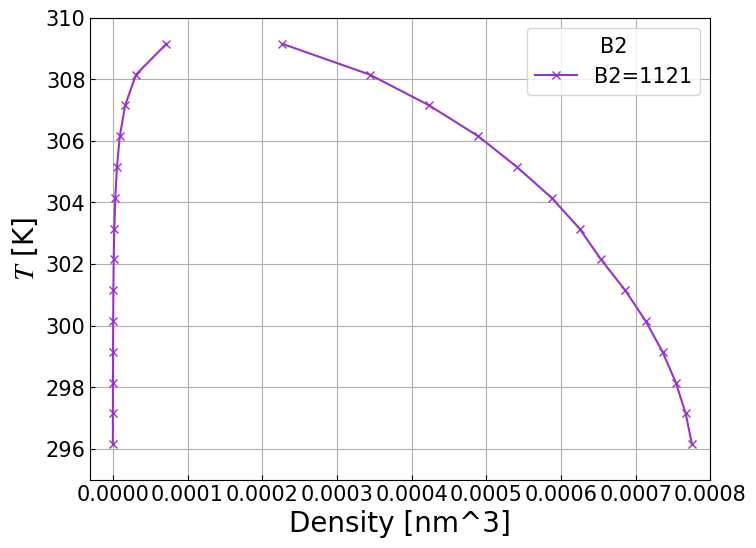

In [4]:
# Sets fonts and that sort of stuff for the plot
plt.rcParams['mathtext.fontset'] = 'stix' 
plt.rcParams["font.size"] = 15 
plt.rcParams['xtick.labelsize'] = 15 
plt.rcParams['ytick.labelsize'] = 15 
plt.figure(figsize = (8, 6))


# Plots the data
colors = ["firebrick", "darkorange", "yellow", "mediumseagreen", "royalblue", "darkorchid", "brown", "black"]


for B2 in B2s:
    data = np.loadtxt(f"b2binodals/f{B2:.1f}")
    plt.plot(data.T[1], data.T[0], 'x-', label=f"B2={B2}", color = colors[B2s.index(B2) - 3])
    plt.plot(data.T[2], data.T[0] , 'x-', color = colors[B2s.index(B2)-3])



# Plot upkeep etc
plt.xlabel("Density [nm^3]", fontsize=20)
plt.ylabel("$T$ [K]",fontsize=20)
plt.legend(title="B2")
plt.xlim(-0.00003, 0.00080)
plt.ylim(295, 310)
plt.grid(which= "both")
plt.tick_params(axis='x', which="both", direction='in')
plt.tick_params(axis='y', which="both", direction='in')      
plt.savefig("binodals_multivalence.png")